# Caminos Mínimos y la Matemática de la Relajación de Aristas
### Matemáticas Discretas: Algoritmos de Dijkstra y Bellman-Ford

* Ramírez Velázques Daniel 183682
* Torres Aguilera Isaac 185070


* **Historia:**
  * El **Algoritmo de Dijkstra** fue derivado por el científico de la computación holandés Edsger Wybe Dijkstra en 1956 y publicado en 1959.
  * El **Algoritmo de Bellman-Ford** fue desarrollado en conjunto por Richard Bellman, Samuel End y Lester Ford.
* **Objetivo de la clase:** Encontrar el camino de peso mínimo desde un origen $s$ a todos los demás vértices en un grafo dirigido y pesado $G=(V, E)$.

## El Problema del Camino Mínimo (Single-Source)

* **Definición:** Encontrar los caminos más cortos desde un vértice de origen $v$ (o $s$) a todos los demás vértices en el grafo.
* **El significado del "Peso":** El peso $w(u,v)$ representa una medida sobre la arista $(u,v)$, como distancia, tiempo o costo.
* **Cantidad de aristas:** En un grafo con $|V|$ vértices, el camino mas corto contiene $|V|-1$ aristas.

## Aplicaciones en el Mundo Real

**¿Dónde se utilizan estos algoritmos?**
* Mapas digitales y navegación (Google Maps).
* Sistemas de Enrutamiento (Routing Systems) en redes de telecomunicaciones.


## Consideración Previa (El ancestro: BFS)

**Búsqueda en Anchura (BFS) en Grafos No Ponderados**
* BFS explora los vértices por niveles,la primera vez que se alcanza cada nodo, se ha encontrado por el camino más corto.

## Concepto Central: "Relajación" Matemática

**La base de los algoritmos de caminos mínimos**
* **Camino mas corto actual:**  $d[v]$, que representa el peso del camino mínimo desde el vértice $s$ (origen) hasta el vértice $v$ (destino).
* **La Desigualdad del Triángulo:** Para cualquier arista $(u,v)$, el camino mínimo a $v$ no puede ser mayor que el camino mínimo a $u$ más el peso de la arista que los une.


## Concepto Central: "Relajación" Matemática

**El Paso de Relajación:** podemos mejorar $d[v]$ pasando por $u$?:
  * **Si** $d[v] > d[u] + w(u,v)$
  * **Entonces** $d[v] = d[u] + w(u,v)$

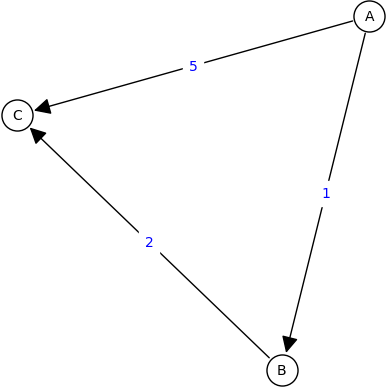

In [1]:
from exampleGraphs import get_simple_triangle
G, _ = get_simple_triangle()
pos = G.layout(layout='spring')

p = G.plot(
    pos=pos,
    edge_labels=True,
    vertex_size=500,
    vertex_color='white',
    figsize=[4, 4],
)
p.show()

## Algoritmo de Dijkstra: La Estrategia Voraz (Greedy)

* **Restriccion:** Todas las aristas deben tener pesos no negativos ($w(u,v) \ge 0$).

* En cada paso, selecciona el vértice $u$ con el valor de $d[u]$ más pequeño. Al elegir el mínimo absoluto, asumimos que no existe un camino más corto a través de otros vértices no visitados.

## Implementación de Dijkstra

**Pseudocódigo (CLRS):**
```text
DIJKSTRA(G, w, s)
1  INITIALIZE-SINGLE-SOURCE(G, s)
2  S ← Ø
3  Q ← V[G]  // Cola de prioridad
4  while Q ≠ Ø
5      do u ← EXTRACT-MIN(Q)
6         S ← S U {u}
7         for each vertex v ∈ Adj[u]
8             do RELAX(u, v, w)
```

## Implementación en Python
```python
def dijkstra(V, Adj, s):
    d, pi = initialize_single_source(V, s)
    Q = [(d[v], v) for v in V]
    heapq.heapify(Q)
    while Q:
        du, u = heapq.heappop(Q)
        if du > d[u]: continue
        for v, weight in Adj.get(u, []):
            if relax(u, v, weight, d, pi):
                heapq.heappush(Q, (d[v], v))
    return d, pi
```

## Simulacion de Dijkstra 

In [2]:
from exampleGraphs import get_clrs_graph, get_all_graphs, get_negative_edge_graph
from interactiveAlgorithms import launch_case, launch_visualizer
import ipywidgets as widgets

G_clrs, s_clrs = get_clrs_graph()
launch_case(G_clrs, s_clrs, algo_name="Dijkstra")

## Ejercicios de practica

In [3]:
from exampleGraphs import get_ejercicios_graphs
from interactiveAlgorithms import launch_visualizer

launch_visualizer(get_ejercicios_graphs())

## El Límite de Dijkstra y la Llegada de Bellman-Ford

**¿Dónde falla Dijkstra?**
Si existe una arista con **peso negativo**, la suposición de que $d[u]$ es el mínimo absoluto se vuelve falsa.

**Algoritmo de Bellman-Ford: Pesos Negativos**
* **Definición:** Genera el camino más corto en un grafo dirigido ponderado en el que el peso de las aristas puede ser negativo.
* **Fuerza bruta:** Bellman-Ford relaja **todas** las aristas del grafo. Repite este proceso exactamente $|V|-1$ veces. (El camino mas corto tiene $|V|-1$ aristas).

## Implementación de Bellman-Ford y Ciclos Negativos

**Pseudocódigo (CLRS):**
```text
BELLMAN-FORD(G, w, s)
1  INITIALIZE-SINGLE-SOURCE(G, s)
2  for i ← 1 to |V[G]| - 1
3       do for each edge (u, v) ∈ E[G]
4              do RELAX(u, v, w)
5  for each edge (u, v) ∈ E[G]
6       do if d[v] > d[u] + w(u, v)
7             then return FALSE // Ciclo negativo detectado
8  return TRUE
```

**¿Qué es un ciclo negativo?**
* **Definición:** Un ciclo donde la suma de los pesos de sus aristas es $< 0$.
* El camino mas corto no está bien definido, el peso tiende a $-\infty$.
* Si despues de $|V|-1$ pasadas aún se puede relajar una arista, significa que hay un **ciclo negativo**.

## Implementación en Python

**Implementación en Python:**
```python
def bellman_ford(V, E_weighted, s):
    d, pi = initialize_single_source(V, s)
    for i in range(len(V) - 1):
        for u, v, w in E_weighted:
            relax(u, v, w, d, pi)
    for u, v, w in E_weighted:
        if d[v] > d[u] + w:
            return False, d, pi # Ciclo negativo
    return True, d, pi
```

## Simulación de Bellman-Ford

In [4]:
G_neg, s_neg = get_negative_edge_graph()
launch_case(G_neg, s_neg, algo_name="Bellman-Ford")

## Conclusión y Comparativa

**Resumen de Algoritmos**

| Algoritmo | Estrategia | Pesos Negativos | Eficiencia |
|---|---|---|---|
| **Dijkstra** | Voraz (Greedy) | No permitidos | Alta (Eficaz) |
| **Bellman-Ford** | Fuerza bruta | Permitidos | Media (Robusto) |
